# Reinforcement learning: a rover, a drone, and three ways to estimate value

We investigate what changes when an algorithm knows the world's dynamics versus learning
through experience. Run top to bottom in a fresh Python session. All implementation code is
embedded here; the notebook requires no repository clone or local data files.

[Read the article](https://github.com/anshubansal2000/ReinforcementLearning/blob/main/blog/reinforcement-learning.md)
· [Repository](https://github.com/anshubansal2000/ReinforcementLearning)

**Colab:** run the installation cell first. No GPU is required. Save a copy in Drive to preserve
your notebook. Runtime files are temporary; the final optional cell downloads the results.
If Colab resets, rerun from the top: visible old outputs do not mean definitions remain in memory.

**Local:** use the README's uv instructions and select the project's Python kernel.

Rover task specification adapted from [Vizuara AI Labs, Lecture 01](https://rl-bootcamp-decks.vercel.app/pdfs/lecture-01-assignment.pdf).

In [1]:
import sys
if "google.colab" in sys.modules:
    %pip install -q "gymnasium==1.3.0" "numpy==2.1.3" "matplotlib==3.10.0"

In [2]:
"""Reproducible tabular RL experiments. Run: python rl_experiments.py.

The notebook embeds this source, so it also works as a standalone Colab upload.
Rover task specification: Vizuara AI Labs, RL in Production, Lecture 01.
"""
from pathlib import Path
import argparse
import json
import platform

import gymnasium as gym
from gymnasium import spaces
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

GAMMA = 0.95
GRID = 5
GOAL = (4, 4)
CRATERS = {(2, 2), (1, 3)}
MOVES = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
PERP = {0: [3, 1], 1: [0, 2], 2: [1, 3], 3: [2, 0]}

def rc(s):
    return divmod(int(s), GRID)

def idx(r, c):
    return r * GRID + c

In [3]:
np.set_printoptions(precision=2, suppress=True, linewidth=110)
print("Gymnasium:", gym.__version__)
frozen = gym.make("FrozenLake-v1", is_slippery=True)
print("reset:", frozen.reset(seed=0))
print("step 5-tuple:", frozen.step(1))
frozen.close()

Gymnasium: 1.3.0
reset: (0, {'prob': 1})
step 5-tuple: (0, 0, False, False, {'prob': 0.33333333333333337})


## Experiment 1 · Define the world

States are the 25 grid cells, encoded as `row*5+column`. Actions are 0 up, 1 right,
2 down, 3 left. Intended direction: 80%; each perpendicular slip: 10%. Walls clip movement.
Entering the goal (4,4) gives +10; entering either crater (1,3) or (2,2) gives -10.
Other moves cost -1. Goal and craters terminate the episode. Arrival rewards replace the
ordinary move cost; terminal states have zero remaining reward.

`reset` starts an episode; `step` samples one outcome. `P` exposes the complete model for DP.

In [4]:
class MarsRoverEnv(gym.Env):
    """Twenty-five fully observed cells with perpendicular movement slips."""
    metadata = {"render_modes": ["ansi"]}

    def __init__(self, slip=0.1, render_mode=None):
        super().__init__()
        if not 0 <= slip <= 0.5:
            raise ValueError("slip must lie between 0 and 0.5")
        if render_mode not in (None, "ansi"):
            raise ValueError("Supported render mode: ansi")
        self.slip = slip
        self.render_mode = render_mode
        self.observation_space = spaces.Discrete(25)
        self.action_space = spaces.Discrete(4)
        self.goal = idx(*GOAL)
        self.craters = {idx(*c) for c in CRATERS}
        self.terminals = self.craters | {self.goal}
        self.P = self._build_model()
        self.s = None

    def _move(self, s, a):
        r, c = rc(s)
        dr, dc = MOVES[a]
        return idx(min(max(r + dr, 0), 4), min(max(c + dc, 0), 4))

    def _reward(self, sn):
        return 10.0 if sn == self.goal else -10.0 if sn in self.craters else -1.0

    def _build_model(self):
        P = {s: {a: [] for a in range(4)} for s in range(25)}
        for s in range(25):
            for a in range(4):
                if s in self.terminals:
                    P[s][a] = [(1.0, s, 0.0, True)]
                    continue
                outcomes = {}
                for direction, prob in [(a, 1 - 2*self.slip),
                                        (PERP[a][0], self.slip),
                                        (PERP[a][1], self.slip)]:
                    if prob > 0:
                        sn = self._move(s, direction)
                        outcomes[sn] = outcomes.get(sn, 0.0) + prob
                P[s][a] = [(p, sn, self._reward(sn), sn in self.terminals)
                           for sn, p in outcomes.items()]
        return P

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.s = 0
        return self.s, {}

    def step(self, action):
        if self.s is None:
            raise RuntimeError("Call reset before step")
        if not self.action_space.contains(action):
            raise ValueError("Invalid action")
        tr = self.P[self.s][int(action)]
        i = self.np_random.choice(len(tr), p=[t[0] for t in tr])
        _, self.s, reward, terminated = tr[i]
        return self.s, reward, terminated, False, {}

    def render(self):
        board = np.full((5, 5), ".", dtype="<U1")
        for r, c in CRATERS:
            board[r, c] = "X"
        board[GOAL] = "G"
        if self.s is not None:
            board[rc(self.s)] = "R"
        return "\n".join(" ".join(row) for row in board)

In [5]:
from gymnasium.utils.env_checker import check_env
rover = MarsRoverEnv()
check_env(rover, skip_render_check=True)
assert all(np.isclose(sum(t[0] for t in tr), 1)
           for actions in rover.P.values() for tr in actions.values())
print("Gymnasium API and model probability checks passed")
print("Possible outcomes of requesting right at state 23:", rover.P[23][1])

if "MarsRover-v0" not in gym.registry:
    gym.register(id="MarsRover-v0", entry_point=MarsRoverEnv)
demo = gym.make("MarsRover-v0")
demo.action_space.seed(7)
s, _ = demo.reset(seed=7)
print("Random episode: (state, action, reward, next_state)")
for steps in range(10_000):
    a = int(demo.action_space.sample())
    result = demo.step(a)
    assert len(result) == 5
    sn, reward, terminated, truncated, _ = result
    print((s, a, reward, sn))
    s = sn
    if terminated or truncated:
        break
else:
    raise RuntimeError("Episode exceeded diagnostic guard")
assert terminated and s in demo.unwrapped.terminals
print("Ended after", steps+1, "steps at", rc(s))
demo.close()

Gymnasium API and model probability checks passed
Possible outcomes of requesting right at state 23: [(0.8, 24, 10.0, True), (0.1, 18, -1.0, False), (0.1, 23, -1.0, False)]
Random episode: (state, action, reward, next_state)
(0, 3, -1.0, 0)
(0, 2, -1.0, 1)
(1, 2, -1.0, 6)
(6, 3, -1.0, 5)
(5, 2, -1.0, 10)
(10, 3, -1.0, 15)
(15, 3, -1.0, 15)
(15, 0, -1.0, 15)
(15, 0, -1.0, 10)
(10, 1, -1.0, 11)
(11, 1, -10.0, 12)
Ended after 11 steps at (2, 2)


## Experiment 2 · Calculate values using the model

Bellman's idea: evaluate the immediate reward and the value of what comes next. For each
action, average across possible outcomes; then take the best action. At state 23 with zero
initial values, requesting right gives `0.8*10 + 0.1*(-1) + 0.1*(-1) = 7.8`.

Value iteration repeats in-place sweeps until the largest change is below 1e-6. It performs
control: the extracted greedy policy is optimal up to numerical tolerance. We check against
an independent linear-equation evaluation of that policy.

In [6]:
def action_values(env, s, V, gamma):
    return np.array([sum(p * (r + gamma * V[sn] * (not term))
                         for p, sn, r, term in env.P[s][a])
                     for a in range(env.action_space.n)])


def value_iteration(env, gamma=0.95, theta=1e-6):
    V = np.zeros(env.observation_space.n)
    for _ in range(100_000):
        delta = 0.0
        for s in range(len(V)):
            if s in env.terminals:
                continue
            new_value = np.max(action_values(env, s, V, gamma))
            delta = max(delta, abs(new_value - V[s]))
            V[s] = new_value
        if delta < theta:
            break
    else:
        raise RuntimeError("Value iteration failed to converge")
    policy = np.full(len(V), -1, dtype=int)
    for s in range(len(V)):
        if s not in env.terminals:
            policy[s] = np.argmax(action_values(env, s, V, gamma))
    return V, policy


def policy_grid(policy, shape, terminals, goal):
    symbols = ["^", ">", "v", "<"]
    return np.array(["G" if s == goal else "X" if s in terminals else symbols[a]
                     for s, a in enumerate(policy)]).reshape(shape)


def exact_policy_value(env, policy, gamma=0.95):
    """Independent linear solve, used only to verify DP."""
    n = env.observation_space.n
    transition_matrix = np.zeros((n, n))
    rewards = np.zeros(n)
    for s in range(n):
        if s not in env.terminals:
            for p, sn, r, term in env.P[s][policy[s]]:
                rewards[s] += p * r
                if not term:
                    transition_matrix[s, sn] += p
    return np.linalg.solve(np.eye(n) - gamma * transition_matrix, rewards)

In [7]:
V_dp, policy = value_iteration(rover)
print("Optimal stochastic values:")
print(V_dp.reshape(5, 5))
print("Policy (X = crater, G = goal):")
for row in policy_grid(policy, (5, 5), rover.terminals, rover.goal):
    print(" ".join(row))
residual = max(abs(V_dp[s] - max(action_values(rover, s, V_dp, GAMMA)))
               for s in range(25) if s not in rover.terminals)
assert residual < 1e-6
assert np.max(np.abs(V_dp - exact_policy_value(rover, policy))) < 2e-5
print("Bellman residual:", residual)
print("DP start value:", V_dp[0])

dry_rover = MarsRoverEnv(slip=0)
V_dry, policy_dry = value_iteration(dry_rover)
print("No-slip values:")
print(V_dry.reshape(5, 5))
print("No-slip policy:")
for row in policy_grid(policy_dry, (5, 5), dry_rover.terminals, dry_rover.goal):
    print(" ".join(row))
print("No-slip minus stochastic values:")
print((V_dry - V_dp).reshape(5, 5))
assert np.isclose(V_dry[0], -sum(GAMMA**t for t in range(7)) + 10*GAMMA**7)

Optimal stochastic values:
[[-1.42 -1.5  -1.52 -0.21  2.24]
 [-0.18 -0.29 -2.26  0.    4.02]
 [ 1.13  1.25  0.    4.56  7.28]
 [ 2.51  4.    5.73  7.59  9.42]
 [ 3.8   5.53  7.4   9.42  0.  ]]
Policy (X = crater, G = goal):
v v > > v
v v < X v
v v X v v
v > v v v
> > > > G
Bellman residual: 1.2269102578343904e-07
DP start value: -1.4161242807269079
No-slip values:
[[ 0.95  2.05  3.21  4.44  5.72]
 [ 2.05  3.21  2.05  0.    7.07]
 [ 3.21  4.44  0.    7.07  8.5 ]
 [ 4.44  5.72  7.07  8.5  10.  ]
 [ 5.72  7.07  8.5  10.    0.  ]]
No-slip policy:
> > > > v
> v ^ X v
> v X > v
> > > > v
> > > > G
No-slip minus stochastic values:
[[2.37 3.55 4.74 4.65 3.48]
 [2.24 3.5  4.31 0.   3.06]
 [2.08 3.19 0.   2.51 1.22]
 [1.93 1.72 1.35 0.91 0.58]
 [1.92 1.54 1.1  0.58 0.  ]]


Removing slip raises the start value from -1.416 to 0.950. Adjacent to a crater, reliable
movement avoids accidental entries. It also avoids detours and wasted moves. Terminal cells
remain zero because their arrival rewards were already paid. Keep the stochastic policy
for the next comparison.

## Experiment 3 · Learn by driving

MC and TD evaluate that fixed policy; neither changes the chosen actions. Both start at zero,
use alpha 0.02, gamma 0.95, and seed 42, and receive identical trajectories. Only reset and step
are exposed to the learners. MC computes returns backward, then updates every visit in time
order. TD updates after every step. Unexpected truncation or episodes longer than 10,000 steps
raise errors, avoiding silently biased incomplete returns.

In [8]:
class ExperienceOnly:
    """Restrict the learner's interface to sampled experience."""
    __slots__ = ("__env",)
    def __init__(self, env):
        self.__env = env
    def reset(self, seed=None):
        return self.__env.reset(seed=seed)
    def step(self, action):
        return self.__env.step(action)


def monte_carlo(env, policy, n_states=25, episodes=20_000,
                alpha=0.02, gamma=0.95, seed=42, checkpoints=(1000, 5000, 20000)):
    V = np.zeros(n_states)
    visits = np.zeros(n_states, dtype=int)
    history = np.zeros(episodes)
    snapshots = {}
    for ep in range(1, episodes + 1):
        s, _ = env.reset(seed=seed if ep == 1 else None)
        trajectory = []
        for _ in range(10_000):
            sn, r, terminated, truncated, _ = env.step(int(policy[s]))
            if truncated:
                raise RuntimeError("MC needs a complete episode")
            trajectory.append((s, r))
            s = sn
            if terminated:
                break
        else:
            raise RuntimeError("MC episode exceeded diagnostic guard")
        returns = np.zeros(len(trajectory))
        G = 0.0
        for t in reversed(range(len(trajectory))):
            G = trajectory[t][1] + gamma * G
            returns[t] = G
        for (s, _), G in zip(trajectory, returns):
            visits[s] += 1
            V[s] += alpha * (G - V[s])
        history[ep - 1] = V[0]
        if ep in checkpoints:
            snapshots[ep] = V.copy()
    return V, snapshots, history, visits


def td_zero(env, policy, n_states=25, episodes=20_000,
            alpha=0.02, gamma=0.95, seed=42, checkpoints=(1000, 5000, 20000)):
    V = np.zeros(n_states)
    visits = np.zeros(n_states, dtype=int)
    history = np.zeros(episodes)
    snapshots = {}
    for ep in range(1, episodes + 1):
        s, _ = env.reset(seed=seed if ep == 1 else None)
        for _ in range(10_000):
            sn, r, terminated, truncated, _ = env.step(int(policy[s]))
            if truncated:
                raise RuntimeError("Unexpected truncation in this experiment")
            target = r if terminated else r + gamma * V[sn]
            visits[s] += 1
            V[s] += alpha * (target - V[s])
            s = sn
            if terminated:
                break
        else:
            raise RuntimeError("TD episode exceeded diagnostic guard")
        history[ep - 1] = V[0]
        if ep in checkpoints:
            snapshots[ep] = V.copy()
    return V, snapshots, history, visits

In [9]:
class TwoStepExperience:
    def reset(self, seed=None):
        self.t = 0
        return 0, {}
    def step(self, action):
        self.t += 1
        return (1, -1.0, False, False, {}) if self.t == 1 else (2, 10.0, True, False, {})

test_policy = np.array([0, 0, -1])
assert np.allclose(monte_carlo(TwoStepExperience(), test_policy, n_states=3,
                             episodes=1, alpha=1)[0], [8.5, 10, 0])
assert np.allclose(td_zero(TwoStepExperience(), test_policy, n_states=3,
                         episodes=1, alpha=1)[0], [-1, 10, 0])
print("Hand-calculated MC and TD checks passed")

mc = monte_carlo(ExperienceOnly(MarsRoverEnv()), policy)
td = td_zero(ExperienceOnly(MarsRoverEnv()), policy)
assert np.array_equal(mc[3], td[3])
for name, result in [("MC", mc), ("TD(0)", td)]:
    for ep, values in result[1].items():
        print(f"\n{name}, {ep:,} episodes")
        print(values.reshape(5, 5))
    print("Visit counts:")
    print(result[3].reshape(5, 5))

Hand-calculated MC and TD checks passed



MC, 1,000 episodes
[[-1.54 -1.43 -0.32 -0.01  0.6 ]
 [-0.37 -0.55 -0.45  0.    1.08]
 [ 0.78  0.92  0.    0.    1.53]
 [ 2.3   3.9   5.78  7.26  3.45]
 [ 3.63  5.35  7.02  9.25  0.  ]]

MC, 5,000 episodes
[[-1.5  -1.24 -0.63  0.42  1.64]
 [-0.32  0.23 -1.    0.    2.73]
 [ 0.99  0.95  0.    0.42  4.12]
 [ 2.6   3.77  5.57  7.3   8.63]
 [ 4.09  5.74  7.67  9.55  0.  ]]

MC, 20,000 episodes
[[-1.89 -1.79 -1.97 -1.16  1.33]
 [-0.61 -0.66 -2.27  0.    3.42]
 [ 0.73  0.36  0.    0.88  7.02]
 [ 1.97  3.71  5.52  7.27  9.39]
 [ 3.37  4.84  7.05  8.91  0.  ]]
Visit counts:
[[22494  2260   285   273   251]
 [20401  4166   432     0   214]
 [18948  6186     0    16   187]
 [18777  9391 10166  3402   550]
 [16703 15772 23091 23584     0]]

TD(0), 1,000 episodes
[[-1.62 -2.17 -0.31 -0.75 -0.27]
 [-0.29 -1.15 -0.8   0.   -0.35]
 [ 1.04  0.11  0.    0.    0.1 ]
 [ 2.5   3.78  5.7   6.53  3.34]
 [ 3.78  5.45  7.13  9.1   0.  ]]

TD(0), 5,000 episodes
[[-1.29 -1.36 -1.39 -1.52 -1.04]
 [ 0.04 -0.3  -1

In [10]:
def run_experiment(episodes=20_000, seed=42, alpha=0.02):
    rover = MarsRoverEnv()
    V_dp, policy = value_iteration(rover)
    residual = max(abs(V_dp[s] - max(action_values(rover, s, V_dp, GAMMA)))
                   for s in range(25) if s not in rover.terminals)
    assert residual < 1e-6
    assert np.max(np.abs(V_dp - exact_policy_value(rover, policy))) < 2e-5
    V_dry, policy_dry = value_iteration(MarsRoverEnv(slip=0))
    assert np.isclose(V_dry[0], -sum(GAMMA**t for t in range(7)) + 10*GAMMA**7)
    mc = monte_carlo(ExperienceOnly(MarsRoverEnv()), policy, episodes=episodes, seed=seed, alpha=alpha)
    td = td_zero(ExperienceOnly(MarsRoverEnv()), policy, episodes=episodes, seed=seed, alpha=alpha)
    assert np.array_equal(mc[3], td[3])
    V_drone, drone_policy = value_iteration(WindyDroneEnv())
    metrics = {"dp_start": float(V_dp[0]), "dry_start": float(V_dry[0]),
               "bellman_residual": float(residual), "drone_start": float(V_drone[0]),
               "config": {"episodes": episodes, "seed": seed, "alpha": alpha, "gamma": GAMMA,
                          "slip": 0.1, "paired_trajectories": True, "start_state": 0},
               "versions": {"python": platform.python_version(), "gymnasium": gym.__version__,
                            "numpy": np.__version__, "matplotlib": matplotlib.__version__}}
    for name, result in [("MC", mc), ("TD", td)]:
        tail = result[2][-min(5000, episodes):]
        hits = []
        if episodes >= 500:
            rmse = np.sqrt(np.convolve((result[2]-V_dp[0])**2, np.ones(500)/500, mode="valid"))
            hits = np.flatnonzero(rmse < 0.5)
        metrics[name] = {"final": float(result[0][0]), "tail_std": float(tail.std()),
                         "tail_rmse": float(np.sqrt(np.mean((tail-V_dp[0])**2))),
                         "first_500_episode_rmse_below_0.5": int(hits[0]+500) if len(hits) else None}
    return dict(dp=V_dp, policy=policy, no_slip=V_dry, policy_dry=policy_dry,
                mc=mc, td=td, drone=V_drone, drone_policy=drone_policy, metrics=metrics)


def plot_convergence(data, output):
    plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    count = len(data["mc"][2])
    for name, key, color in [("MC", "mc", "#b45309"), ("TD(0)", "td", "#0369a1")]:
        for ax in axes:
            ax.plot(np.arange(1, count+1), data[key][2], label=name, color=color, alpha=0.8, linewidth=0.7)
    for ax in axes:
        ax.axhline(data["dp"][0], linestyle="--", color="#111827", label="DP reference")
        ax.set(xlabel="Completed episodes", ylabel="Estimated V(start)")
        ax.grid(alpha=0.18)
    axes[0].set_title(f"Fixed policy, alpha = {data['metrics']['config']['alpha']}")
    axes[1].set(title="Early learning", xlim=(1, min(1500, count)))
    axes[0].legend()
    fig.savefig(Path(output) / "convergence.png", dpi=160)
    return fig


def save_results(data, output="results"):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    (output / "metrics.json").write_text(json.dumps(data["metrics"], indent=2)+"\n", encoding="utf-8")
    checkpoints = {key: {str(ep): values.reshape(5, 5).tolist() for ep, values in data[key][1].items()}
                   for key in ("mc", "td")}
    (output / "checkpoints.json").write_text(json.dumps(checkpoints, indent=2)+"\n", encoding="utf-8")
    np.savez(output / "values.npz", dp=data["dp"], policy=data["policy"], no_slip=data["no_slip"],
             mc=data["mc"][0], td=data["td"][0], mc_history=data["mc"][2], td_history=data["td"][2],
             visits=data["mc"][3], drone=data["drone"], drone_policy=data["drone_policy"])
    np.savetxt(output / "visits.csv", data["mc"][3].reshape(5, 5), delimiter=",", fmt="%d")
    return plot_convergence(data, output)

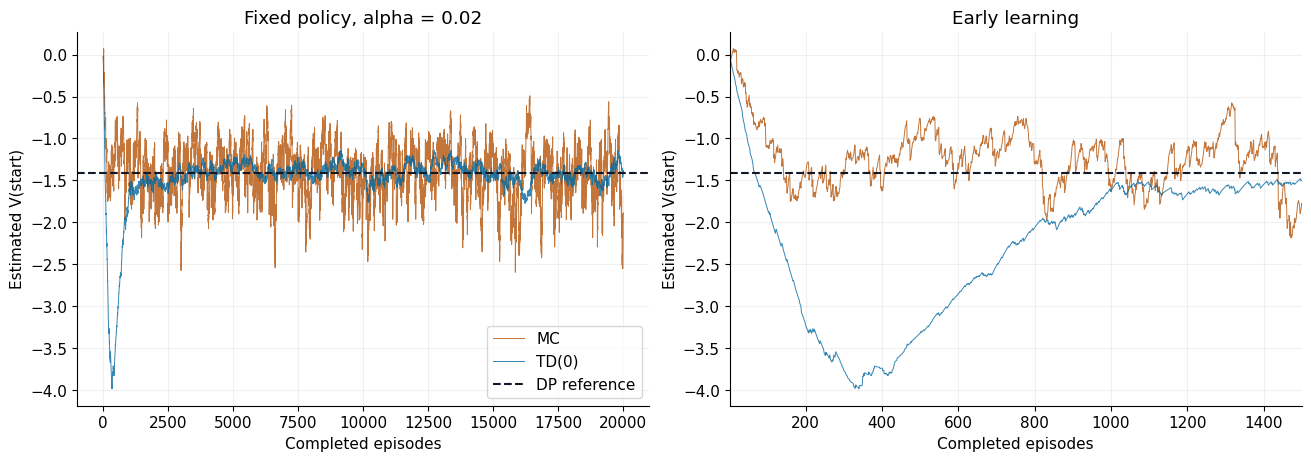

Start-state diagnostics (one paired seed):
MC {'final': -1.8889009268977217, 'tail_std': 0.3368539696274805, 'tail_rmse': 0.3403649892137354, 'first_500_episode_rmse_below_0.5': 500}
TD {'final': -1.396947526273843, 'tail_std': 0.10413190611654952, 'tail_rmse': 0.10924492396367255, 'first_500_episode_rmse_below_0.5': 1203}


In [11]:
data = {"dp": V_dp, "mc": mc, "td": td, "metrics": {"config": {"alpha": 0.02}}}
Path("results").mkdir(exist_ok=True)
plot_convergence(data, "results")
plt.show()

print("Start-state diagnostics (one paired seed):")
metrics = {"dp_start": float(V_dp[0]), "dry_start": float(V_dry[0]),
           "bellman_residual": float(residual),
           "config": {"episodes": 20000, "seed": 42, "alpha": 0.02, "gamma": GAMMA,
                      "slip": 0.1, "paired_trajectories": True, "start_state": 0},
           "versions": {"python": platform.python_version(), "gymnasium": gym.__version__,
                        "numpy": np.__version__, "matplotlib": matplotlib.__version__}}
for name, result in [("MC", mc), ("TD", td)]:
    tail = result[2][-5000:]
    rmse = np.sqrt(np.convolve((result[2]-V_dp[0])**2, np.ones(500)/500, mode="valid"))
    hits = np.flatnonzero(rmse < 0.5)
    metrics[name] = {"final": float(result[0][0]), "tail_std": float(tail.std()),
                     "tail_rmse": float(np.sqrt(np.mean((tail-V_dp[0])**2))),
                     "first_500_episode_rmse_below_0.5": int(hits[0]+500) if len(hits) else None}
    print(name, metrics[name])

MC uses full returns, which can vary substantially with later slips and hazards. TD uses one
reward and a bootstrapped estimate; this often reduces sampling variability but creates dependence
on initially inaccurate estimates. Here, MC reaches a 500-episode rolling RMSE below 0.5 earlier,
while TD has lower start-value variability during the last 5,000 episodes. Constant alpha leaves
residual noise. A single paired run cannot establish a universal winner.

State 13 was visited only 16 times: its MC/TD estimates remain far from DP even after 20,000
episodes. An accurate start-state curve is not evidence of accurate values everywhere.

## Experiment 4 · A second world

Windy drone: S is a 3x4 grid; A is the four directions; P applies the requested action with
probability 0.8 or moves east with probability 0.2. R is +8 at delivery (2,3), -6 at a tower
(1,2), -0.5 otherwise. Gamma is 0.95. Both special cells terminate episodes; start is (0,0).
The same DP algorithm applies without modification.

In [12]:
class WindyDroneEnv(gym.Env):
    """Twelve cells; a 20% eastward gust replaces the intended move."""
    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Discrete(12)
        self.action_space = spaces.Discrete(4)
        self.goal = 11
        self.terminals = {6, 11}
        self.s = None
        self.P = {s: {} for s in range(12)}
        for s in range(12):
            for a in range(4):
                if s in self.terminals:
                    self.P[s][a] = [(1.0, s, 0.0, True)]
                    continue
                outcomes = {}
                for direction, prob in [(a, 0.8), (1, 0.2)]:
                    r, c = divmod(s, 4)
                    dr, dc = MOVES[direction]
                    sn = min(max(r+dr, 0), 2)*4 + min(max(c+dc, 0), 3)
                    outcomes[sn] = outcomes.get(sn, 0.0) + prob
                self.P[s][a] = [(p, sn, 8.0 if sn == 11 else -6.0 if sn == 6 else -0.5,
                                 sn in self.terminals) for sn, p in outcomes.items()]

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.s = 0
        return self.s, {}

    def step(self, action):
        if self.s is None:
            raise RuntimeError("Call reset first")
        if not self.action_space.contains(action):
            raise ValueError("Invalid action")
        tr = self.P[self.s][int(action)]
        i = self.np_random.choice(len(tr), p=[t[0] for t in tr])
        _, self.s, reward, term = tr[i]
        return self.s, reward, term, False, {}

In [13]:
drone = WindyDroneEnv()
check_env(drone, skip_render_check=True)
V_drone, drone_policy = value_iteration(drone)
print("Drone optimal values:")
print(V_drone.reshape(3, 4))
for row in policy_grid(drone_policy, (3, 4), drone.terminals, drone.goal):
    print(" ".join(row))
assert np.max(np.abs(V_drone - exact_policy_value(drone, drone_policy))) < 2e-5

Drone optimal values:
[[4.3  5.05 5.85 6.68]
 [4.97 3.8  0.   7.78]
 [6.24 7.1  8.   0.  ]]
> > > v
v v X v
> > > G


The drone favors the top route from the start. Eastward wind aligns with travel across the top;
at the right wall a gust causes a delay, rather than a tower collision. Start value: about 4.301.

## What these experiments teach

1. A real rover may not know the complete transition model. MC and TD require sampled experience;
   model-based planning can still help when a useful approximate model is available.
2. MC updates after a completed episode; TD updates after each transition. On the transition into
   a crater the episode ends immediately, so both can update the preceding state at that boundary.
3. To improve a policy from experience, learn action values and explore, for example using
   epsilon-greedy Q-learning. DP already performed control here; MC and TD performed evaluation.

Next experiments: repeat across seeds, change alpha, and broaden the starting-state distribution.
Report these as changed experiments rather than silently altering the baseline.

In [14]:
metrics["drone_start"] = float(V_drone[0])
data.update(policy=policy, no_slip=V_dry, policy_dry=policy_dry,
            drone=V_drone, drone_policy=drone_policy, metrics=metrics)
fig = save_results(data)
plt.close(fig)
print("Saved results/metrics.json, checkpoints.json, values.npz, visits.csv, convergence.png")
print("All notebook checks passed.")

Saved results/metrics.json, checkpoints.json, values.npz, visits.csv, convergence.png
All notebook checks passed.


**Optional Colab download:** run this cell to download the result files before the runtime expires.
Use File → Download → Download .ipynb to save the executed notebook itself.

In [15]:
if "google.colab" in sys.modules:
    import shutil
    from google.colab import files
    shutil.make_archive("rl-results", "zip", "results")
    files.download("rl-results.zip")